In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:

import os
from scipy import stats

OUTPUT = r"E:\2ndYear2ndSemester\Project(DSMA299)\remittance-forecasting\output"

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_pred_1 = np.load(f"{OUTPUT}/xgb_pred_1m.npy").flatten()
xgb_true_1 = np.load(f"{OUTPUT}/xgb_true_1m.npy").flatten()
xgb_pred_3 = np.load(f"{OUTPUT}/xgb_pred_3m.npy").flatten()
xgb_true_3 = np.load(f"{OUTPUT}/xgb_true_3m.npy").flatten()
xgb_pred_6 = np.load(f"{OUTPUT}/xgb_pred_6m.npy").flatten()
xgb_true_6 = np.load(f"{OUTPUT}/xgb_true_6m.npy").flatten()

# ── LSTM ──────────────────────────────────────────────────────────────────────
_lstm_p1_raw = np.load(f"{OUTPUT}/lstm_pred_1.npy")
_lstm_t1_raw = np.load(f"{OUTPUT}/lstm_true_1.npy")
_lstm_p3_raw = np.load(f"{OUTPUT}/lstm_pred_3.npy")
_lstm_t3_raw = np.load(f"{OUTPUT}/lstm_true_3.npy")
_lstm_p6_raw = np.load(f"{OUTPUT}/lstm_pred6.npy")
_lstm_t6_raw = np.load(f"{OUTPUT}/lstm_true6.npy")

lstm_pred_1 = _lstm_p1_raw[:, 0]
lstm_true_1 = _lstm_t1_raw[:, 0]
lstm_pred_3 = _lstm_p3_raw[:, 2]
lstm_true_3 = _lstm_t3_raw[:, 2]
lstm_pred_6 = _lstm_p6_raw[:, 5]
lstm_true_6 = _lstm_t6_raw[:, 5]

# ── VAR-X ─────────────────────────────────────────────────────────────────────
varx_pred_1 = np.load(f"{OUTPUT}/varx_pred.npy").flatten()
varx_true_1 = np.load(f"{OUTPUT}/varx_true.npy").flatten()

# ── SARIMA ────────────────────────────────────────────────────────────────────
sarima_pred_1 = np.load(f"{OUTPUT}/sarima_pred.npy").flatten()
sarima_true_1 = np.load(f"{OUTPUT}/sarima_true.npy").flatten()

# ── Metric functions ──────────────────────────────────────────────────────────
def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred)**2))

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))
def diebold_mariano(actual, pred1, pred2, h=1):
    e1    = actual - pred1
    e2    = actual - pred2
    d     = e1**2 - e2**2
    T     = len(d)
    d_bar = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    nw_sum = 0.0
    for lag in range(1, h):
        g = np.cov(d[lag:], d[:-lag])[0, 1] if T > lag else 0
        nw_sum += 2 * (1 - lag / h) * g
    var_d = max((gamma0 + nw_sum) / T, 1e-10)
    DM = d_bar / np.sqrt(var_d)
    p  = 2 * (1 - stats.norm.cdf(abs(DM)))
    return round(float(DM), 4), round(float(p), 4)


print(f"XGBoost 1m:  {xgb_pred_1.shape}")
print(f"LSTM 1m:     {lstm_pred_1.shape}")
print(f"VAR-X 1m:    {varx_pred_1.shape}")
print(f"SARIMA 1m:   {sarima_pred_1.shape}")
print(f"XGBoost 3m:  {xgb_pred_3.shape}, LSTM 3m: {lstm_pred_3.shape}")
print(f"XGBoost 6m:  {xgb_pred_6.shape}, LSTM 6m: {lstm_pred_6.shape}")


XGBoost 1m:  (23,)
LSTM 1m:     (23,)
VAR-X 1m:    (23,)
SARIMA 1m:   (23,)
XGBoost 3m:  (21,), LSTM 3m: (21,)
XGBoost 6m:  (18,), LSTM 6m: (18,)


In [3]:
# ── Align all models to same test window ──────────────────────────────
# XGBoost: 1m=23, 3m=21, 6m=18
# LSTM:    1m=23, 3m=21, 6m=18  ← already matches!
# VAR-X:   1m=23 ← already matches!
# SARIMA:  1m=23 ← already matches!

# No dropping needed — all models now have same lengths!

print('=== Alignment Verification ===')
print(f'1m — XGBoost: {xgb_pred_1.shape}, LSTM: {lstm_pred_1.shape}, VAR-X: {varx_pred_1.shape}, SARIMA: {sarima_pred_1.shape}')
print(f'3m — XGBoost: {xgb_pred_3.shape}, LSTM: {lstm_pred_3.shape}')
print(f'6m — XGBoost: {xgb_pred_6.shape}, LSTM: {lstm_pred_6.shape}')

# Actuals should match between models
print()
print('1m actuals match (XGB vs LSTM):', np.allclose(xgb_true_1, lstm_true_1, rtol=0.01))
print('3m actuals match (XGB vs LSTM):', np.allclose(xgb_true_3, lstm_true_3, rtol=0.01))
print('6m actuals match (XGB vs LSTM):', np.allclose(xgb_true_6, lstm_true_6, rtol=0.01))


=== Alignment Verification ===
1m — XGBoost: (23,), LSTM: (23,), VAR-X: (23,), SARIMA: (23,)
3m — XGBoost: (21,), LSTM: (21,)
6m — XGBoost: (18,), LSTM: (18,)

1m actuals match (XGB vs LSTM): True
3m actuals match (XGB vs LSTM): True
6m actuals match (XGB vs LSTM): True


In [4]:
print("=== 1-MONTH HORIZON ===\n")
print(f"{'Model':<12} {'MAPE (%)':>10} {'RMSE':>12} {'MAE':>12}")
print("-" * 50)
for name, true, pred in [
    ('SARIMA',  sarima_true_1, sarima_pred_1),
    ('VAR-X',   varx_true_1,   varx_pred_1),
    ('XGBoost', xgb_true_1,    xgb_pred_1),
    ('LSTM',    lstm_true_1,   lstm_pred_1),
]:
    print(f"{name:<12} {mape(true,pred):>10.2f} {rmse(true,pred):>12,.0f} {mae(true,pred):>12,.0f}")

print("\n=== 3-MONTH HORIZON ===\n")
print(f"{'Model':<12} {'MAPE (%)':>10} {'RMSE':>12} {'MAE':>12}")
print("-" * 50)
for name, true, pred in [
    ('XGBoost', xgb_true_3, xgb_pred_3),
    ('LSTM',    lstm_true_3, lstm_pred_3),
]:
    print(f"{name:<12} {mape(true,pred):>10.2f} {rmse(true,pred):>12,.0f} {mae(true,pred):>12,.0f}")

print("\n=== 6-MONTH HORIZON ===\n")
print(f"{'Model':<12} {'MAPE (%)':>10} {'RMSE':>12} {'MAE':>12}")
print("-" * 50)
for name, true, pred in [
    ('XGBoost', xgb_true_6, xgb_pred_6),
    ('LSTM',    lstm_true_6, lstm_pred_6),
]:
    print(f"{name:<12} {mape(true,pred):>10.2f} {rmse(true,pred):>12,.0f} {mae(true,pred):>12,.0f}")

=== 1-MONTH HORIZON ===

Model          MAPE (%)         RMSE          MAE
--------------------------------------------------
SARIMA            10.20       20,066       15,360
VAR-X             10.28       18,103       14,242
XGBoost           12.22       27,276       19,216
LSTM              11.43       20,545       15,749

=== 3-MONTH HORIZON ===

Model          MAPE (%)         RMSE          MAE
--------------------------------------------------
XGBoost           13.94       33,314       23,209
LSTM              12.22       21,629       17,073

=== 6-MONTH HORIZON ===

Model          MAPE (%)         RMSE          MAE
--------------------------------------------------
XGBoost           14.39       33,990       24,349
LSTM              14.93       30,474       23,884


In [5]:
print("=== DIEBOLD-MARIANO TEST ===\n")
print(f"{'Comparison':<25} {'Horizon':<10} {'DM Stat':>10} {'p-value':>10} {'Sig?':>8} {'Better':>12}")
print("-" * 80)

dm_tests = [
    ('XGBoost vs SARIMA', '1m', xgb_true_1, xgb_pred_1, sarima_pred_1, 1),
    ('XGBoost vs VAR-X',  '1m', xgb_true_1, xgb_pred_1, varx_pred_1,   1),
    ('XGBoost vs LSTM',   '1m', xgb_true_1, xgb_pred_1, lstm_pred_1,   1),
    ('LSTM vs SARIMA',    '1m', lstm_true_1, lstm_pred_1, sarima_pred_1, 1),
    ('LSTM vs VAR-X',     '1m', lstm_true_1, lstm_pred_1, varx_pred_1,  1),
    ('SARIMA vs VAR-X',   '1m', sarima_true_1, sarima_pred_1, varx_pred_1, 1),
    ('XGBoost vs LSTM',   '3m', xgb_true_3, xgb_pred_3, lstm_pred_3,   3),
    ('XGBoost vs LSTM',   '6m', xgb_true_6, xgb_pred_6, lstm_pred_6,   6),
]

for name, horizon, actual, pred1, pred2, h in dm_tests:
    dm, p  = diebold_mariano(actual, pred1, pred2, h)
    sig    = "Yes " if p < 0.05 else "No "
    better = name.split(' vs ')[0] if dm < 0 else name.split(' vs ')[1]
    print(f"{name:<25} {horizon:<10} {dm:>10.4f} {p:>10.4f} {sig:>8} {better:>12}")

=== DIEBOLD-MARIANO TEST ===

Comparison                Horizon       DM Stat    p-value     Sig?       Better
--------------------------------------------------------------------------------
XGBoost vs SARIMA         1m             2.3342     0.0196     Yes        SARIMA
XGBoost vs VAR-X          1m             1.3758     0.1689      No         VAR-X
XGBoost vs LSTM           1m             0.9624     0.3358      No          LSTM
LSTM vs SARIMA            1m             0.0830     0.9339      No        SARIMA
LSTM vs VAR-X             1m             1.7017     0.0888      No         VAR-X
SARIMA vs VAR-X           1m             0.3906     0.6961      No         VAR-X
XGBoost vs LSTM           3m             1.2575     0.2086      No          LSTM
XGBoost vs LSTM           6m             0.9024     0.3668      No          LSTM


In [6]:
# ── DM Test 3-Month Horizon ───────────────────────────────────────────────────
print("=== DIEBOLD-MARIANO TEST RESULTS (3-Month Horizon) ===\n")
print(f"{'Comparison':<25} {'DM Stat':>10} {'p-value':>10} {'Significant?':>15} {'Better Model':>15}")
print("-" * 80)

comparisons_3m = {
    'XGBoost vs LSTM': diebold_mariano(xgb_true_3, xgb_pred_3, lstm_pred_3, 3),
}

for name, (dm, p) in comparisons_3m.items():
    sig    = "Yes " if p < 0.05 else "No "
    better = name.split(' vs ')[0] if dm < 0 else name.split(' vs ')[1]
    print(f"{name:<25} {dm:>10.4f} {p:>10.4f} {sig:>15} {better:>15}")



=== DIEBOLD-MARIANO TEST RESULTS (3-Month Horizon) ===

Comparison                   DM Stat    p-value    Significant?    Better Model
--------------------------------------------------------------------------------
XGBoost vs LSTM               1.2575     0.2086             No             LSTM


In [7]:
# ── DM Test 6-Month Horizon ───────────────────────────────────────────────────
print("\n=== DIEBOLD-MARIANO TEST RESULTS (6-Month Horizon) ===\n")
print(f"{'Comparison':<25} {'DM Stat':>10} {'p-value':>10} {'Significant?':>15} {'Better Model':>15}")
print("-" * 80)

comparisons_6m = {
    'XGBoost vs LSTM': diebold_mariano(xgb_true_6, xgb_pred_6, lstm_pred_6, 6),
}

for name, (dm, p) in comparisons_6m.items():
    sig    = "Yes " if p < 0.05 else "No "
    better = name.split(' vs ')[0] if dm < 0 else name.split(' vs ')[1]
    print(f"{name:<25} {dm:>10.4f} {p:>10.4f} {sig:>15} {better:>15}")


=== DIEBOLD-MARIANO TEST RESULTS (6-Month Horizon) ===

Comparison                   DM Stat    p-value    Significant?    Better Model
--------------------------------------------------------------------------------
XGBoost vs LSTM               0.9024     0.3668             No             LSTM


In [8]:
rows = []

# 1m horizon
for name, pred, true in [
    ('SARIMAX',  sarima_pred_1, sarima_true_1),
    ('VAR-X',    varx_pred_1,   varx_true_1),
    ('XGBoost',  xgb_pred_1,    xgb_true_1),
    ('LSTM',     lstm_pred_1,   lstm_true_1),
]:
    rows.append({
        'Model':    name,
        'Horizon':  '1m',
        'RMSE':     round(rmse(true, pred), 1),
        'MAE':      round(mae(true, pred),  1),
        'MAPE (%)': round(mape(true, pred), 2),
    })

# 3m horizon
for name, pred, true in [
    ('XGBoost', xgb_pred_3,  xgb_true_3),
    ('LSTM',    lstm_pred_3, lstm_true_3),
]:
    rows.append({
        'Model':    name,
        'Horizon':  '3m',
        'RMSE':     round(rmse(true, pred), 1),
        'MAE':      round(mae(true, pred),  1),
        'MAPE (%)': round(mape(true, pred), 2),
    })

# 6m horizon
for name, pred, true in [
    ('XGBoost', xgb_pred_6,  xgb_true_6),
    ('LSTM',    lstm_pred_6, lstm_true_6),
]:
    rows.append({
        'Model':    name,
        'Horizon':  '6m',
        'RMSE':     round(rmse(true, pred), 1),
        'MAE':      round(mae(true, pred),  1),
        'MAPE (%)': round(mape(true, pred), 2),
    })

results_df = pd.DataFrame(rows)
print('=' * 55)
print('MODEL COMPARISON — POINT METRICS')
print('=' * 55)
print(results_df.to_string(index=False))

MODEL COMPARISON — POINT METRICS
  Model Horizon    RMSE     MAE  MAPE (%)
SARIMAX      1m 20065.9 15360.1     10.20
  VAR-X      1m 18102.7 14242.1     10.28
XGBoost      1m 27275.9 19216.2     12.22
   LSTM      1m 20544.5 15748.7     11.43
XGBoost      3m 33313.6 23208.9     13.94
   LSTM      3m 21628.6 17072.6     12.22
XGBoost      6m 33990.4 24348.7     14.39
   LSTM      6m 30474.3 23883.7     14.93


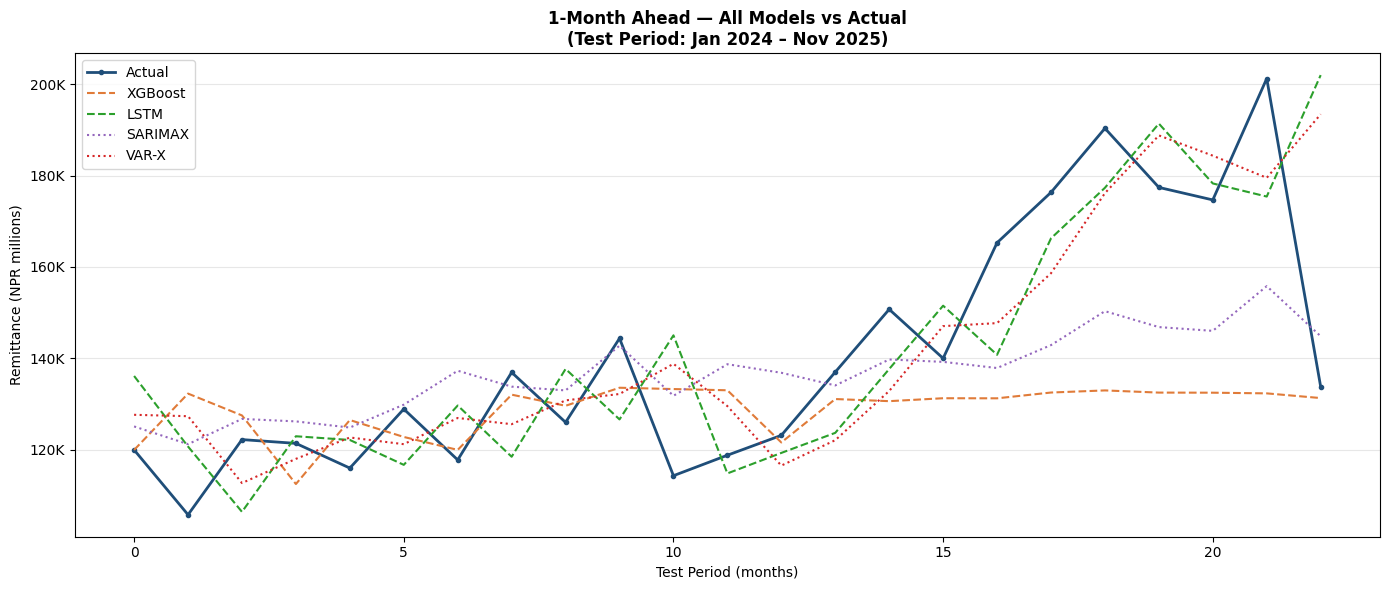

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(xgb_true_1,    color='#1f4e79', linewidth=2.0, label='Actual',  marker='o', markersize=3)
ax.plot(xgb_pred_1,    color='#e07b39', linewidth=1.5, label='XGBoost', linestyle='--')
ax.plot(lstm_pred_1,   color='#2ca02c', linewidth=1.5, label='LSTM',    linestyle='--')
ax.plot(sarima_pred_1, color='#9467bd', linewidth=1.5, label='SARIMAX', linestyle=':')
ax.plot(varx_pred_1,   color='#d62728', linewidth=1.5, label='VAR-X',   linestyle=':')

ax.set_title('1-Month Ahead — All Models vs Actual\n(Test Period: Jan 2024 – Nov 2025)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Test Period (months)')
ax.set_ylabel('Remittance (NPR millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

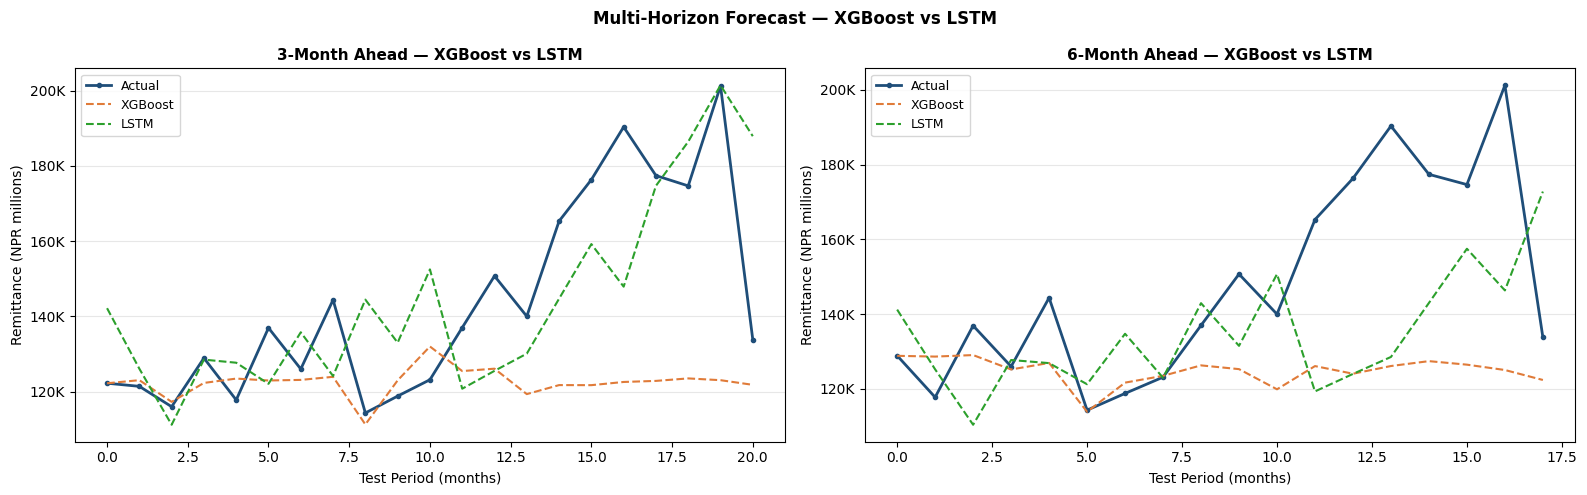

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, horizon, xgb_p, xgb_t, lstm_p, lstm_t in [
    (axes[0], '3-Month', xgb_pred_3, xgb_true_3, lstm_pred_3, lstm_true_3),
    (axes[1], '6-Month', xgb_pred_6, xgb_true_6, lstm_pred_6, lstm_true_6),
]:
    ax.plot(xgb_t,  color='#1f4e79', linewidth=2.0, label='Actual',  marker='o', markersize=3)
    ax.plot(xgb_p,  color='#e07b39', linewidth=1.5, label='XGBoost', linestyle='--')
    ax.plot(lstm_p, color='#2ca02c', linewidth=1.5, label='LSTM',    linestyle='--')
    ax.set_title(f'{horizon} Ahead — XGBoost vs LSTM', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Period (months)')
    ax.set_ylabel('Remittance (NPR millions)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Multi-Horizon Forecast — XGBoost vs LSTM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

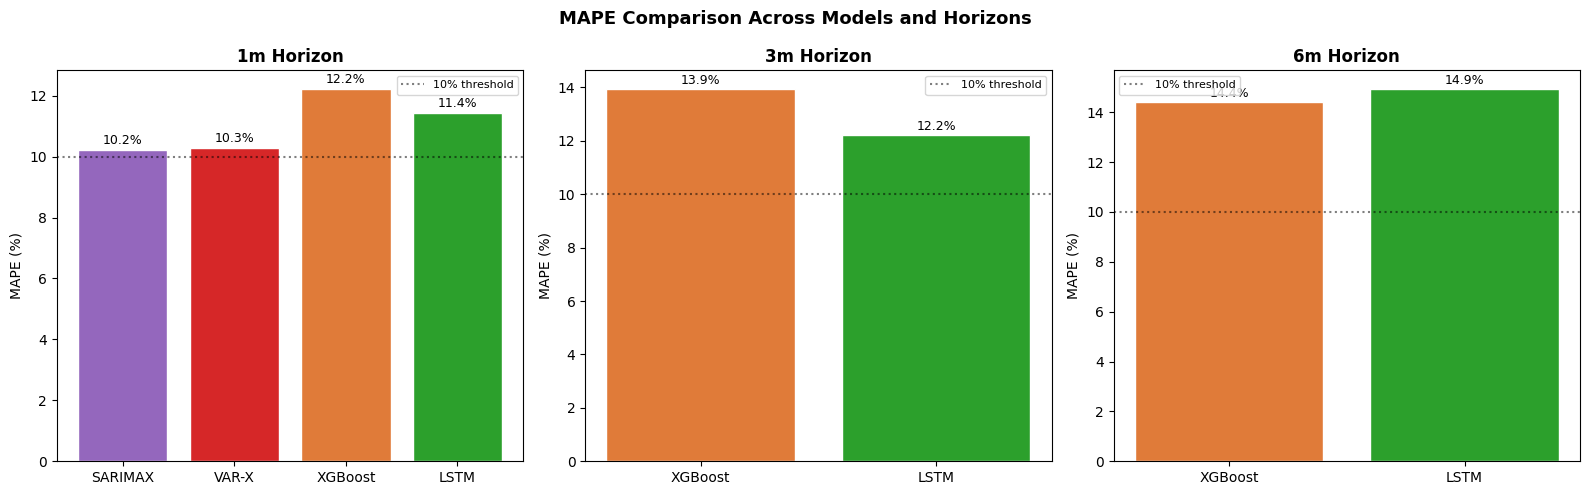

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MAPE Comparison Across Models and Horizons', fontsize=13, fontweight='bold')

colors_map = {'SARIMAX': '#9467bd', 'VAR-X': '#d62728', 'XGBoost': '#e07b39', 'LSTM': '#2ca02c'}

for ax, horizon in zip(axes, ['1m', '3m', '6m']):
    df_h = results_df[results_df['Horizon'] == horizon]
    bars = ax.bar(df_h['Model'], df_h['MAPE (%)'],
                  color=[colors_map[m] for m in df_h['Model']], edgecolor='white')
    ax.set_title(f'{horizon} Horizon', fontweight='bold')
    ax.set_ylabel('MAPE (%)')
    ax.axhline(y=10, color='black', linestyle=':', alpha=0.5, label='10% threshold')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, df_h['MAPE (%)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
results_df.to_csv(f"{OUTPUT}/model_comparison_results.csv", index=False)
print(" Results saved to output/model_comparison_results.csv")
print()
print(results_df.to_string(index=False))

 Results saved to output/model_comparison_results.csv

  Model Horizon    RMSE     MAE  MAPE (%)
SARIMAX      1m 20065.9 15360.1     10.20
  VAR-X      1m 18102.7 14242.1     10.28
XGBoost      1m 27275.9 19216.2     12.22
   LSTM      1m 20544.5 15748.7     11.43
XGBoost      3m 33313.6 23208.9     13.94
   LSTM      3m 21628.6 17072.6     12.22
XGBoost      6m 33990.4 24348.7     14.39
   LSTM      6m 30474.3 23883.7     14.93
